# Set Up

In [62]:
# Set up project root
import sys
import os
import pandas as pd
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [63]:
from notebooks import get_complete_dataset

df = await get_complete_dataset()

Loading complete dataset from disk...


/Users/ruwanjayasinghe/Documents/Rumeth/UCL/data_science/notebooks/_helper.py:52: DtypeWarning: Columns (49,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(complete_data_path, sep='\t')


In [64]:
print(df.head(5))
print(df.info())
df['time_stamp_utc'] = pd.to_datetime(df['time_stamp_utc'])

              time_stamp_utc  \
0  2019-01-01 10:34:00+00:00   
1  2019-01-01 10:34:00+00:00   
2  2019-01-01 10:34:00+00:00   
3  2019-01-01 10:34:00+00:00   
4  2019-01-01 10:34:00+00:00   

                                                 loc     locId  numSpecies_x  \
0  {'locId': 'L6646786', 'name': 'Near Our Resida...  L6646786            16   
1  {'locId': 'L6646786', 'name': 'Near Our Resida...  L6646786            16   
2  {'locId': 'L6646786', 'name': 'Near Our Resida...  L6646786            16   
3  {'locId': 'L6646786', 'name': 'Near Our Resida...  L6646786            16   
4  {'locId': 'L6646786', 'name': 'Near Our Resida...  L6646786            16   

      obsDt_x obsTime      subID      subId userDisplayName  allObsReported  \
0  1 Jan 2019   16:04  S51145808  S51145808    Ajith Gamage            True   
1  1 Jan 2019   16:04  S51145808  S51145808    Ajith Gamage            True   
2  1 Jan 2019   16:04  S51145808  S51145808    Ajith Gamage            True   
3  1 Jan 2

In [65]:
diffs = df['numSpecies_x'].compare(df['numSpecies_y'])

print(diffs)

        self  other
4382    71.0   72.0
4383    71.0   72.0
4384    71.0   72.0
4385    71.0   72.0
4386    71.0   72.0
...      ...    ...
355524  25.0   26.0
355525  25.0   26.0
355526  25.0   26.0
355527  25.0   26.0
355528  25.0   26.0

[10961 rows x 2 columns]


# Data Cleaning

## Duplicates

In [66]:
# check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


## Missing Values

In [67]:
# Known Booleans          
cols_to_check = ['allObsReported', 'obsTimeValid', 'isHotspot', 'present', 'isHighValue_LK', 'isEndemic_LK']
unique_values = df[cols_to_check].apply(pd.unique)
print(unique_values)

# Convert to boolean and set nan values to False
for col in cols_to_check:
    df[col] = df[col].astype('boolean').fillna(False).astype(bool)


# When effortDistanceKm is Null => stationary checklist
df['effortDistanceKm'] = df['effortDistanceKm'].fillna(0).astype(int)

allObsReported         [True, False]
obsTimeValid           [True, False]
isHotspot              [False, True]
present           [False, True, nan]
isHighValue_LK           [nan, True]
isEndemic_LK      [nan, True, False]
dtype: object


## Taxonomic Rollup

In [68]:
# Verify roll up
issf_df = df[df['category'] == 'issf']
print(issf_df[['speciesCode', 'category','reportAs', 'sciName']].head())

    speciesCode category  reportAs             sciName
2       grecou3     issf   grecou1  Centropus sinensis
154     gretit2     issf  cintit13      Parus cinereus
170     gretit2     issf  cintit13      Parus cinereus
212     crehae1     issf    y00839  Nisaetus cirrhatus
308     barswa2     issf    barswa     Hirundo rustica


## Low Quality Observations

In [69]:
# # Drop observations where durationHrs and effortDistanceKm is none (incidental reports)
# cols_to_check = ['durationHrs', 'effortDistanceKm']

# # Drop row only if BOTH 'durationHrs' AND 'effortDistanceKm' are NaN
# df = df.dropna(subset=cols_to_check, how='all')
df = df.dropna(subset=['durationHrs'], how='all')

## Feature Selection

In [ ]:
# Check the differences between obsDt_y, obsDt_x, time_stamp_utc
print(df[['obsDt_x', 'obsDt_y', 'obsTime', 'time_stamp_utc']].head(10))
# -> Drop the columns as they are redundant

# Redundent Temporal Variables
df = df.drop(columns=['obsDt_x', 'obsDt_y', 'obsTime'])

# Drop other redundent columns
df = df.drop(columns=['lat', 'lng',     # same as 'latitude', 'longitude'
                      'subID', 'locID', # same as 'subId', 'locId'
                      'loc', 'obs',     # these are already expanded into multiple columns
                      'name',           # same as 'locName'
                      ])          

# Drop administrative columns that are not useful for analysis
df = df.drop(columns=['checklistId', 
                      'obsId',
                      'creationDt', 
                      'deleteTrack',
                      'lastEditedDt',
                      'subAux','subAuxAi',
                      'projId',	'projectIds', 'protocolId',
                      'submissionMethodCode', 'submissionMethodVersion', 'submissionMethodVersionDisp'
                      ])

# Drop irrelvant observation data
df = df.drop(columns=[
                      'effortDistanceEnteredUnit',
                      'countryCode',
                      'countryName',
                      'subnational1Code',
                      'subnational2Code',
                      'comments',
                      'mediaCounts',
                      'obsAux',
                      'userDoNotCount',
                      'bandingCodes',
                      'comNameCodes',
                      'familyCode',
                      'sciNameCodes',
                      'taxonOrder',
                      'exoticCategory',
                      'numObservers',
                      'howManyAtleast', 
                      'howManyAtmost',
                      'present'
                      ])

# Drop irrelvant weather data
df = df.drop(columns=['cloud_cover_mid', 
                      'cloud_cover_high',
                      'cloud_cover_low',
                      'wind_speed_100m' ,
                      'wind_direction_100m',
                      'wind_direction_10m',
                      ])

      obsDt_x           obsDt_y obsTime            time_stamp_utc
0  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
1  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
2  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
3  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
4  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
5  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
6  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
7  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
8  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00
9  1 Jan 2019  2019-01-01 16:04   16:04 2019-01-01 10:34:00+00:00


In [71]:
# TODO
# if the checklist species is marked as present then use the minimum of counts for that species


# NULL CHECKER
# 1. Calculate the sum of nulls per column
null_counts = df.isnull().sum()

# 2. Filter for columns with at least one missing value
print(null_counts[null_counts > 0])

duration_df = df[df['durationHrs'].isnull()]
print(duration_df.head(10))

userDisplayName                 35
subnational2Name                 8
speciesCode                    104
howManyStr                     104
category                       104
comName                        104
familyComName                  214
familySciName                  214
order                          106
reportAs                    335422
sciName                        104
temperature_2m                  76
apparent_temperature            76
rain                            76
weather_code                    76
cloud_cover                     76
wind_speed_10m                  76
weather_code_description        76
dtype: int64
Empty DataFrame
Columns: [time_stamp_utc, locId, numSpecies_x, subId, userDisplayName, allObsReported, durationHrs, effortDistanceKm, numSpecies_y, obsTimeValid, hierarchicalName, isHotspot, latitude, locName, longitude, subnational1Name, subnational2Name, speciesCode, howManyStr, category, comName, familyComName, familySciName, order, reportAs, sciName, 

# Statistical Analysis

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
# Descriptive Statistics data regarding the mean, standard deviation, inter-quartile range
desc_stats = df.describe()
print(desc_stats)

        numSpecies_x    durationHrs  effortDistanceKm   numSpecies_y  \
count  344645.000000  344645.000000     344645.000000  344645.000000   
mean       26.918464       1.345397          2.149801      26.952679   
std        17.584102       2.301387          6.139147      17.602575   
min         0.000000       0.000000          0.000000       0.000000   
25%        14.000000       0.334000          0.000000      14.000000   
50%        23.000000       0.750000          0.000000      23.000000   
75%        35.000000       1.500000          1.000000      35.000000   
max       141.000000     182.833000         80.000000     141.000000   

            latitude      longitude  temperature_2m  apparent_temperature  \
count  344645.000000  344645.000000   344569.000000         344569.000000   
mean        6.916734      80.332178       26.966324             30.792171   
std         0.778082       0.485677        2.499132              3.079663   
min         5.586396      79.456006        

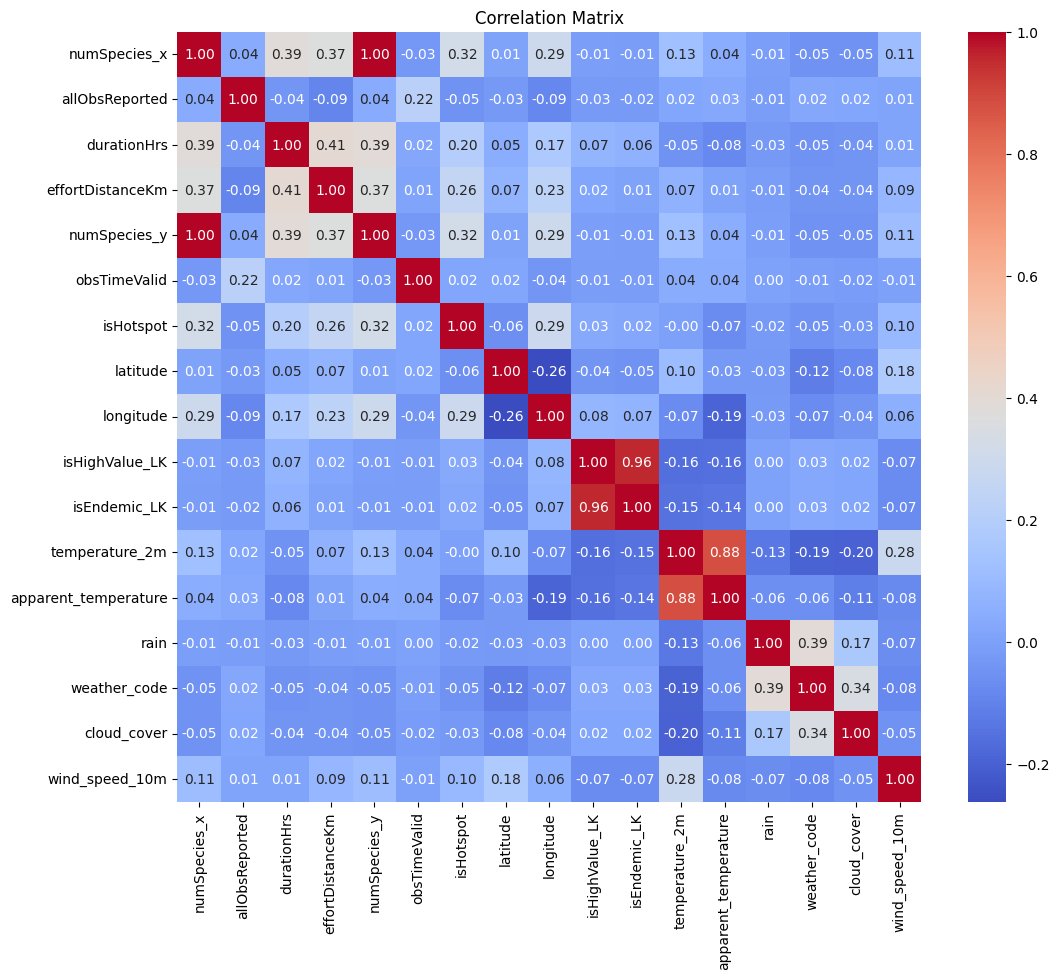

In [74]:
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

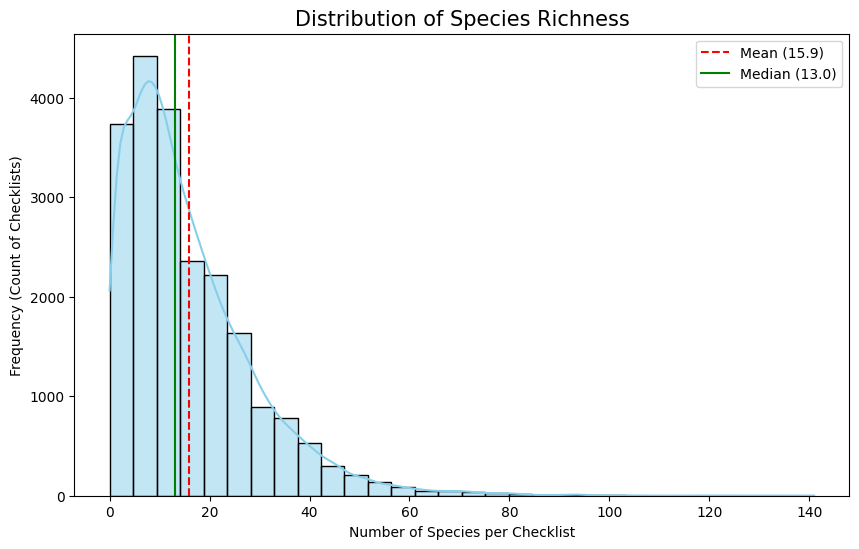

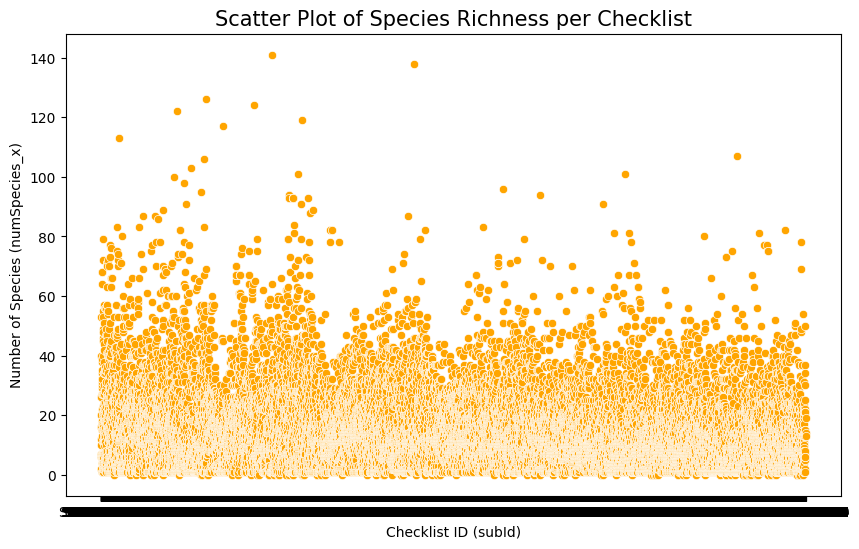

In [75]:
# numSpecies distribution plot

# Note before you doo every plot get only the require columns and drop the duplicates
unique_checklists = df[['subId', 'numSpecies_x']].drop_duplicates()
plt.figure(figsize=(10, 6))

# 2. Create the plot
# kde=True adds the Kernel Density line to help see the "shape"
sns.histplot(data=unique_checklists, x='numSpecies_x', kde=True, color='skyblue', bins=30)

# 3. Add lines for Mean and Median to help identify skew
mean_val = unique_checklists['numSpecies_x'].mean()
median_val = unique_checklists['numSpecies_x'].median()

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean ({mean_val:.1f})')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median ({median_val:.1f})')

# 4. Styling
plt.title('Distribution of Species Richness', fontsize=15)
plt.xlabel('Number of Species per Checklist')
plt.ylabel('Frequency (Count of Checklists)')
plt.legend()

plt.show()

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=unique_checklists, x='subId', y='numSpecies_x', color='orange')
plt.title('Scatter Plot of Species Richness per Checklist', fontsize=15)
plt.xlabel('Checklist ID (subId)')
plt.ylabel('Number of Species (numSpecies_x)')
plt.show()

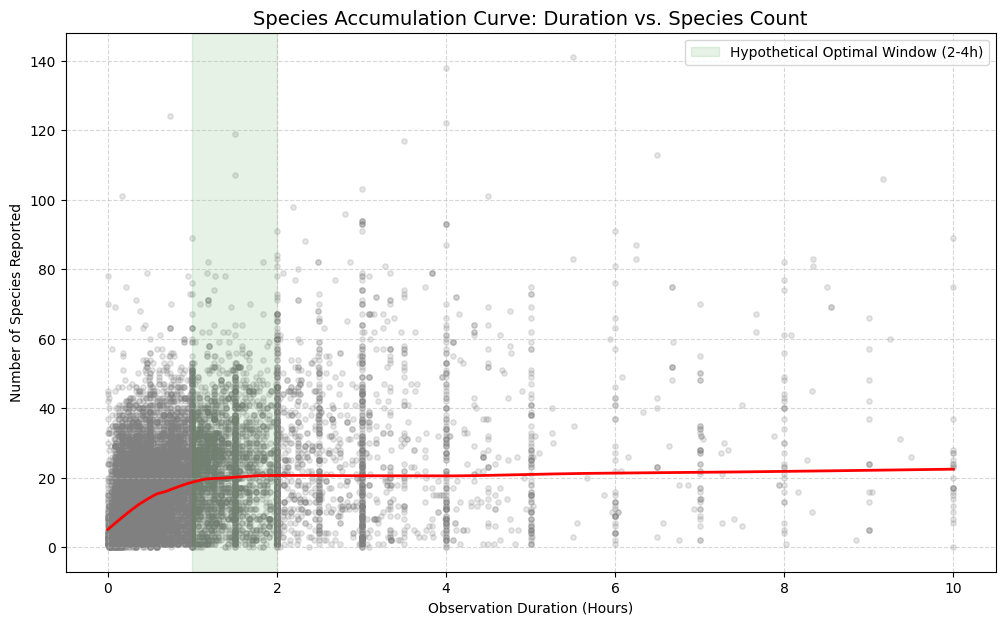

In [87]:
# Temporal Effort vs Reward Plot

# 1. Prepare Data: Ensure unique checklists & remove extreme outliers (e.g., >10 hours)
# (Assuming df currently has one row per species)
plot_df = df[['subId', 'durationHrs', 'numSpecies_x']].drop_duplicates()

# Optional: Filter to realistic birding day (e.g., <= 10 hours) to focus the plot
plot_df = plot_df[plot_df['durationHrs'] <= 10]

plt.figure(figsize=(12, 7))

# 2. Create Scatter with Trendline
# scatter_kws={'alpha': 0.3}: Makes points transparent so you can see density
# lowess=True: Draws a locally weighted regression line (flexible curve) instead of straight line
sns.regplot(
    data=plot_df, 
    x='durationHrs', 
    y='numSpecies_x', 
    scatter_kws={'alpha': 0.2, 's': 15, 'color': 'gray'}, 
    line_kws={'color': 'red', 'linewidth': 2},
    lowess=True
)

# 3. Highlight the "Optimal Window" (2-4 Hours)
plt.axvspan(1, 2, color='green', alpha=0.1, label='Hypothetical Optimal Window (2-4h)')

# 4. Styling
plt.title('Species Accumulation Curve: Duration vs. Species Count', fontsize=14)
plt.xlabel('Observation Duration (Hours)')
plt.ylabel('Number of Species Reported')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

          locId  latitude  longitude  \
442   L11176620  6.840681  79.879284   
5042   L6248950  5.975843  80.522208   
1171  L13464975  6.927894  79.865004   
1337  L14221659  6.048434  80.196954   
5409   L9061236  7.031970  79.963176   

                                       locName  checklist_count  
442                                   Attidiya              851  
5042             Matara--Kirala Kele Sanctuary              551  
1171  Maradana Railway Station (6.928, 79.865)              378  
1337                                wekunagoda              336  
5409                   Sooriyapaluwa Kadawatha              311  


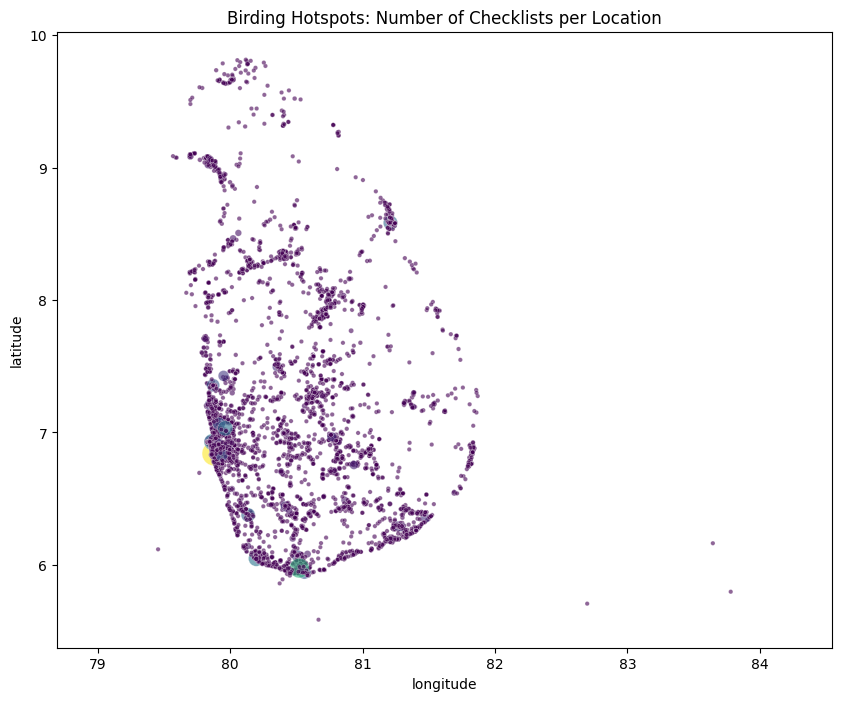

In [77]:
# Spatial Disrtibution of Checklists

# Group by location and count UNIQUE subIds (checklists)
loc_activity = df.groupby(['locId', 'latitude', 'longitude', 'locName'])['subId'].nunique().reset_index()
loc_activity.rename(columns={'subId': 'checklist_count'}, inplace=True)

# Sort to see top locations
print(loc_activity.sort_values('checklist_count', ascending=False).head())

plt.figure(figsize=(10, 8))

# Plot longitude vs latitude
# size='checklist_count': Makes popular spots bigger
# hue='checklist_count': Makes popular spots darker
sns.scatterplot(
    data=loc_activity, 
    x='longitude', 
    y='latitude', 
    size='checklist_count', 
    hue='checklist_count',
    sizes=(10, 300),  # Min and Max bubble size
    palette='viridis',
    alpha=0.6,
    legend=False
)

plt.title('Birding Hotspots: Number of Checklists per Location')
plt.axis('equal')  # Keeps the map aspect ratio correct
plt.show()

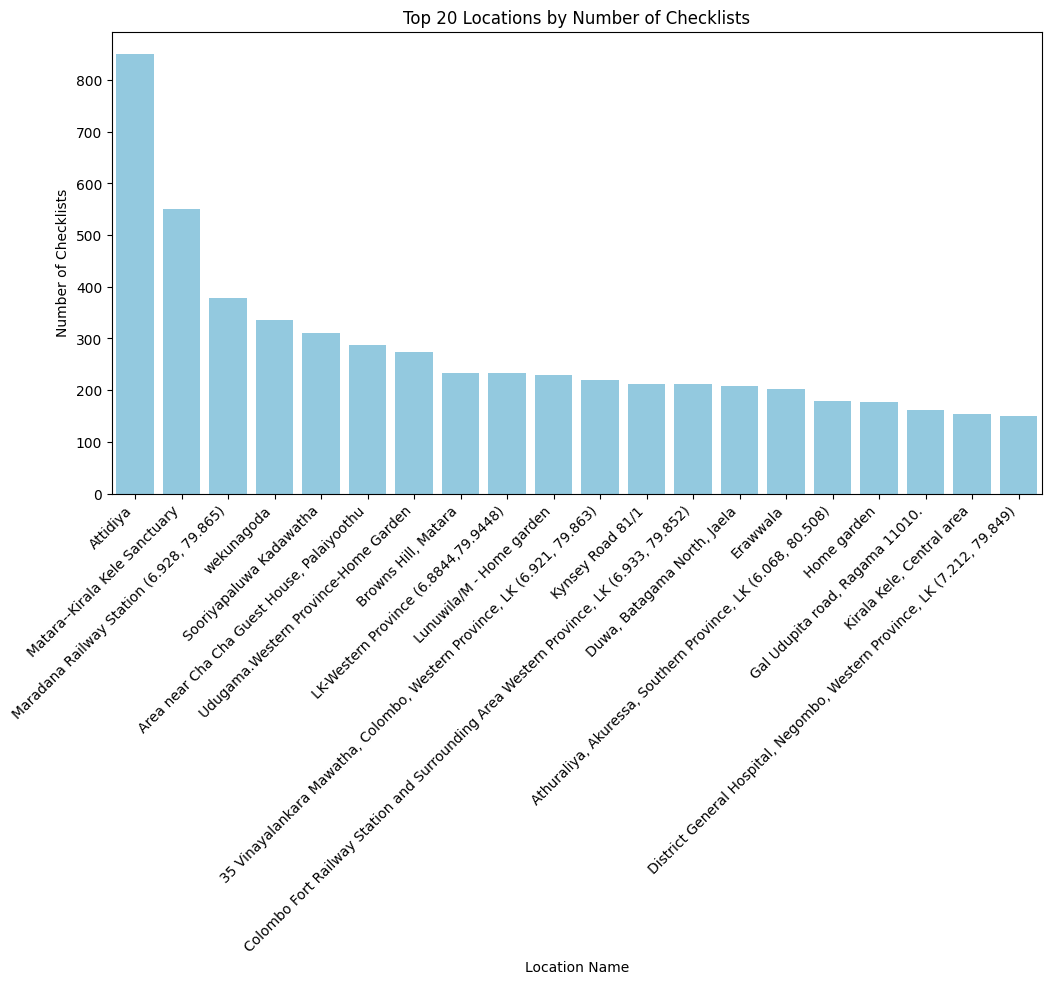

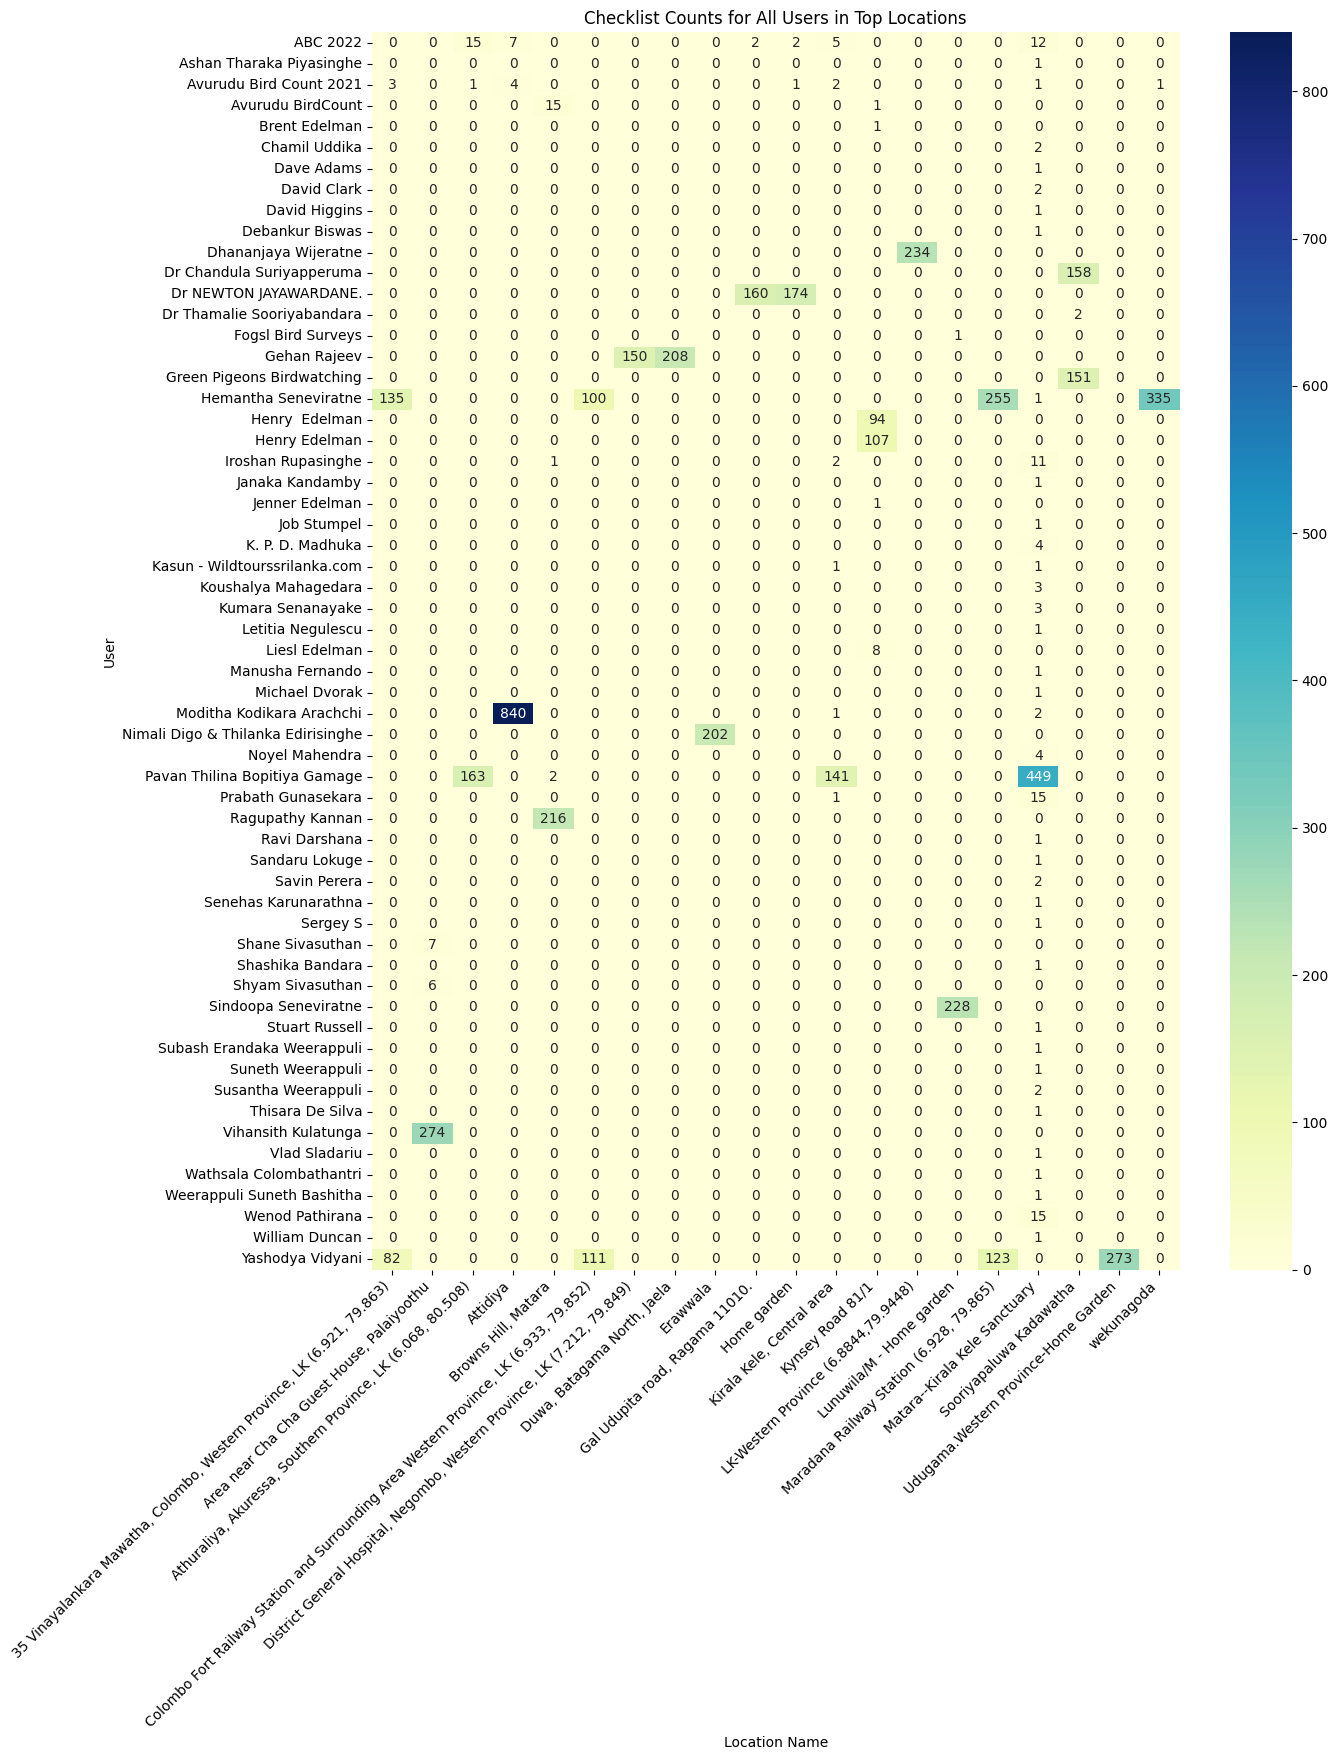

In [78]:
# Bar graph of locations with most checklists
top_locations = loc_activity.sort_values('checklist_count', ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_locations, x='locName', y='checklist_count', color='skyblue')
plt.title('Top 20 Locations by Number of Checklists')
plt.xlabel('Location Name')
plt.ylabel('Number of Checklists')
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot who are the most active contributors to these locations
# Using a heatmap to visualize the contributors across locations clearly
top_locations_ids = top_locations['locId'].tolist()
top_loc_contributors = df[df['locId'].isin(top_locations_ids)]

# Group by location and user (all users)
loc_user_activity = top_loc_contributors.groupby(['locName', 'userDisplayName'])['subId'].nunique().reset_index()
loc_user_activity.rename(columns={'subId': 'checklist_count'}, inplace=True)

# Pivot the data for the heatmap
heatmap_data = loc_user_activity.pivot(index='userDisplayName', columns='locName', values='checklist_count').fillna(0)

# Adjust figure size dynamically based on number of users to ensure readability
n_users = len(heatmap_data.index)
plt.figure(figsize=(14, max(10, n_users * 0.3))) 
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Checklist Counts for All Users in Top Locations')
plt.xlabel('Location Name')
plt.ylabel('User')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

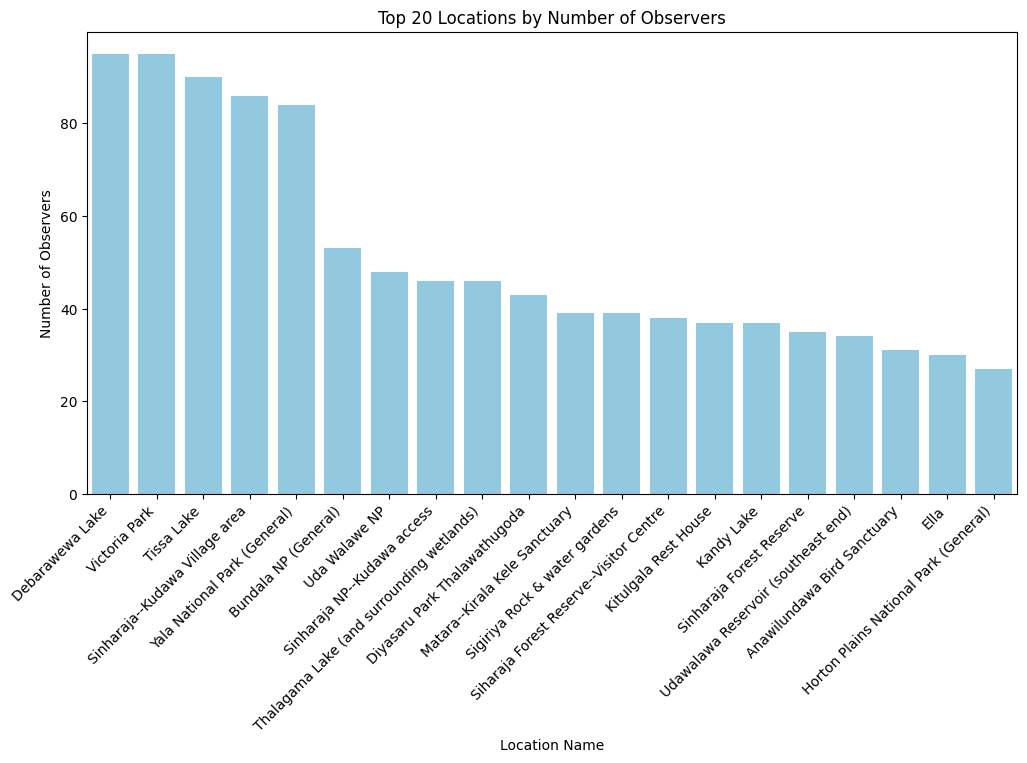

In [84]:
# Top locations by number of users
# Bar graph of locations with most checklists
loc_user_activity = df.groupby(['locId', 'latitude', 'longitude', 'locName'])['userDisplayName'].nunique().reset_index()
loc_user_activity.rename(columns={'userDisplayName': 'user_count'}, inplace=True)
top_locations = loc_user_activity.sort_values('user_count', ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_locations, x='locName', y='user_count', color='skyblue')
plt.title('Top 20 Locations by Number of Observers')
plt.xlabel('Location Name')
plt.ylabel('Number of Observers')
plt.xticks(rotation=45, ha='right')
plt.show()


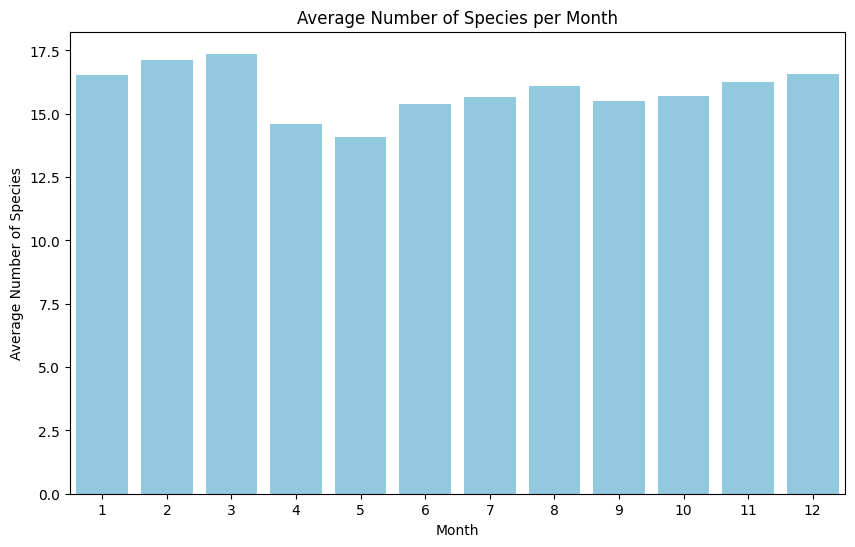

In [79]:
# Bar graph of average numSpecies per month
df['month'] = df['time_stamp_utc'].dt.month
unique_checklists = df[['time_stamp_utc','subId', 'month', 'numSpecies_x']].drop_duplicates()
monthly_avg_species = unique_checklists.groupby('month')['numSpecies_x'].mean().reset_index()
monthly_avg_species.rename(columns={'numSpecies_x': 'avg_numSpecies'}, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg_species, x='month', y='avg_numSpecies', color='skyblue')
plt.title('Average Number of Species per Month')
plt.xlabel('Month')
plt.ylabel('Average Number of Species')
plt.show()

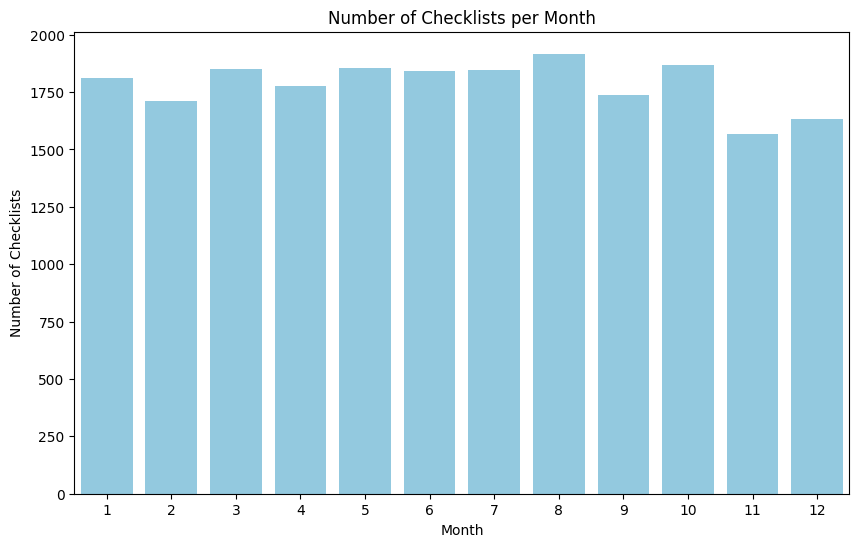

In [80]:
# Bar graph of number of checklists per month
df['month'] = df['time_stamp_utc'].dt.month
unique_checklists = df[['time_stamp_utc','subId', 'month', 'numSpecies_x']].drop_duplicates()
monthly_checklists = unique_checklists.groupby('month')['subId'].nunique().reset_index()
monthly_checklists.rename(columns={'subId': 'checklist_count'}, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_checklists, x='month', y='checklist_count', color='skyblue')
plt.title('Number of Checklists per Month')
plt.xlabel('Month')
plt.ylabel('Number of Checklists')
plt.show()

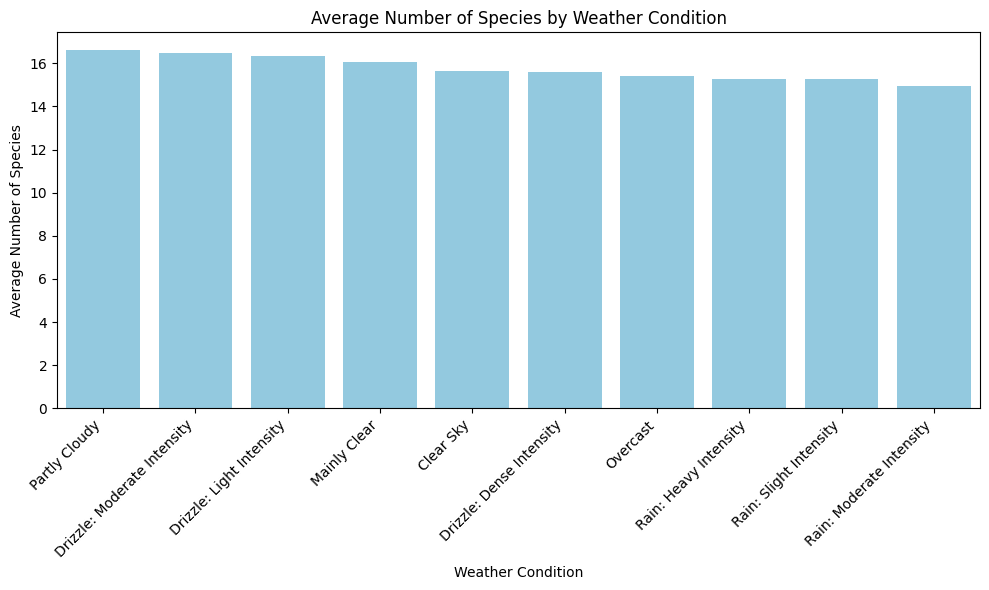

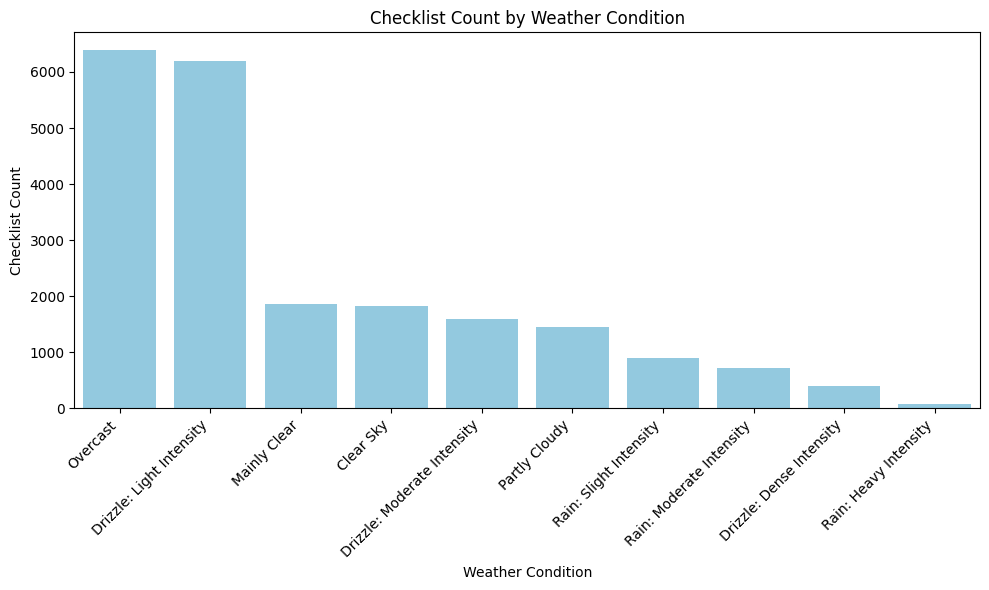

In [81]:
# Does weather_code_description effect numSpecies_x?
unique_checklists = df[['time_stamp_utc','subId', 'weather_code_description', 'numSpecies_x']].drop_duplicates()
weather_species = unique_checklists.groupby('weather_code_description')['numSpecies_x'].mean().reset_index()
weather_species = weather_species.sort_values(by='numSpecies_x', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_species, x='weather_code_description', y='numSpecies_x', color='skyblue')
plt.title('Average Number of Species by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Number of Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# get the subId count for each weather code
weather_checklists = unique_checklists.groupby('weather_code_description')['subId'].count().reset_index()
weather_checklists = weather_checklists.sort_values(by='subId', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_checklists, x='weather_code_description', y='subId', color='skyblue')
plt.title('Checklist Count by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Checklist Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

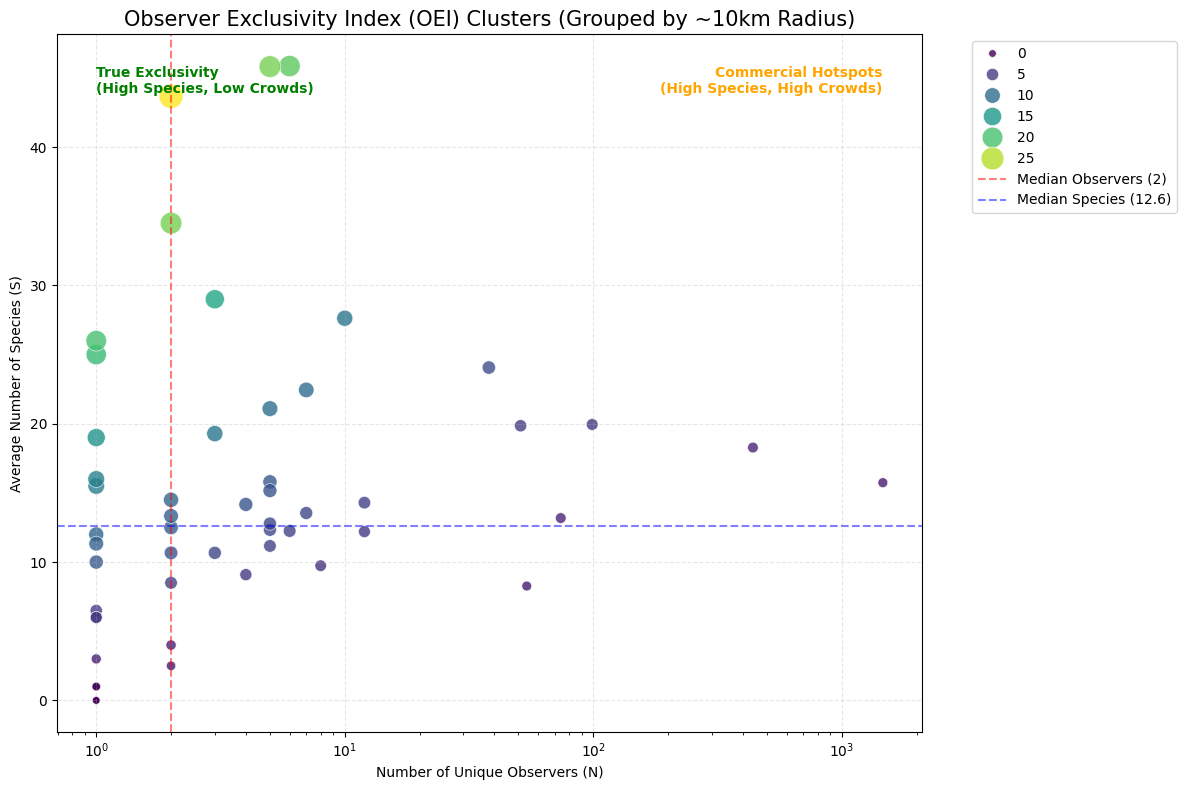

Top 10 Clusters by OEI:
                                         cluster_name  loc_count  \
14              Northern Province, LK (9.445, 80.161)          3   
23                            Wasgamuwa National Park          1   
55                              Ruhunuketha Lake Dam.          2   
10                       Senanayaka Samudra Reservoir          5   
42  Madu Church, Northern Province, LK (8.853, 80....          1   
32              Nrar Sangamankanda LK (7.051, 81.835)          1   
40                             Kaguwatte To Wilachiya          1   
47                                        Maha Oya-LK          1   
54  Badullagammana Road, Bibile, Uva Province, LK ...          1   
28                          Hiripitiya-Madagalla road          2   

    num_observers  avg_numSpecies        OEI  
14              2       43.666667  28.145809  
23              5       45.818182  22.420418  
55              2       34.500000  22.237338  
10              6       45.857143  21.1

In [86]:
import numpy as np
from sklearn.cluster import DBSCAN

# Non-weighted Observer Exlcusivity Index (OEI) Calculation
# numSpecies / ln(number of unique observers + e)

# Create a cluster graphe for OEI 
    # Cluster 1 (High numspecies, Low N): True Exclusivity (The model filters for this when the user selects "Avoid Crowds").
    # Cluster 2 (High numSpecies, High N): Commercial Hotspots.

# Include locName, lat, lon for identification and clustering
unique_checklists = df[['time_stamp_utc','subId', 'locId', 'locName', 'latitude', 'longitude', 'weather_code_description', 'numSpecies_x', 'userDisplayName']].drop_duplicates()

# --- Spatial Clustering ---
# Group locations within a suitable radius (e.g., 10km) to aggregate nearby hotspots.

# 1. Get unique locations with coordinates
locations = unique_checklists[['locId', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)

# 2. Prepare coordinates for DBSCAN (Haversine metric requires radians)
coords = np.radians(locations[['latitude', 'longitude']])

# 3. Define radius (10 km)
kms_per_radian = 6371.0088
epsilon = 10 / kms_per_radian 

# 4. Run DBSCAN
db = DBSCAN(eps=epsilon, min_samples=1, metric='haversine', algorithm='ball_tree').fit(coords)
locations['cluster_label'] = db.labels_

# 5. Merge cluster info back to checklists
unique_checklists = unique_checklists.merge(locations[['locId', 'cluster_label']], on='locId', how='left')

# 6. Determine a representative name for each cluster (most common locName)
cluster_names = unique_checklists.groupby('cluster_label')['locName'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
cluster_names.rename(columns={'locName': 'cluster_name'}, inplace=True)

unique_checklists = unique_checklists.merge(cluster_names, on='cluster_label', how='left')

# Group by CLUSTER
loc_stats = unique_checklists.groupby(['cluster_label', 'cluster_name']).agg(
    num_observers=('userDisplayName', 'nunique'),
    avg_numSpecies=('numSpecies_x', 'mean'),
    loc_count=('locId', 'nunique')
).reset_index()

# Calculate OEI
# Formula: numSpecies / ln(number of unique observers + e)
loc_stats['OEI'] = loc_stats['avg_numSpecies'] / np.log(loc_stats['num_observers'] + np.e)

# Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=loc_stats, 
    x='num_observers', 
    y='avg_numSpecies', 
    hue='OEI', 
    palette='viridis', 
    size='OEI', 
    sizes=(30, 300),
    alpha=0.8
)

# Add reference lines for median values to define quadrants
median_obs = loc_stats['num_observers'].median()
median_species = loc_stats['avg_numSpecies'].median()

plt.axvline(x=median_obs, color='red', linestyle='--', alpha=0.5, label=f'Median Observers ({median_obs:.0f})')
plt.axhline(y=median_species, color='blue', linestyle='--', alpha=0.5, label=f'Median Species ({median_species:.1f})')

# Annotate Clusters
# Cluster 1: High Species, Low Observers (Top Left)
plt.text(x=loc_stats['num_observers'].min(), y=loc_stats['avg_numSpecies'].max(), 
         s='True Exclusivity\n(High Species, Low Crowds)', 
         fontsize=10, color='green', ha='left', va='top', fontweight='bold')

# Cluster 2: High Species, High Observers (Top Right)
plt.text(x=loc_stats['num_observers'].max(), y=loc_stats['avg_numSpecies'].max(), 
         s='Commercial Hotspots\n(High Species, High Crowds)', 
         fontsize=10, color='orange', ha='right', va='top', fontweight='bold')

plt.title('Observer Exclusivity Index (OEI) Clusters (Grouped by ~10km Radius)', fontsize=15)
plt.xlabel('Number of Unique Observers (N)')
plt.ylabel('Average Number of Species (S)')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Show top locations by OEI
print("Top 10 Clusters by OEI:")
print(loc_stats.sort_values('OEI', ascending=False)[['cluster_name', 'loc_count', 'num_observers', 'avg_numSpecies', 'OEI']].head(10))

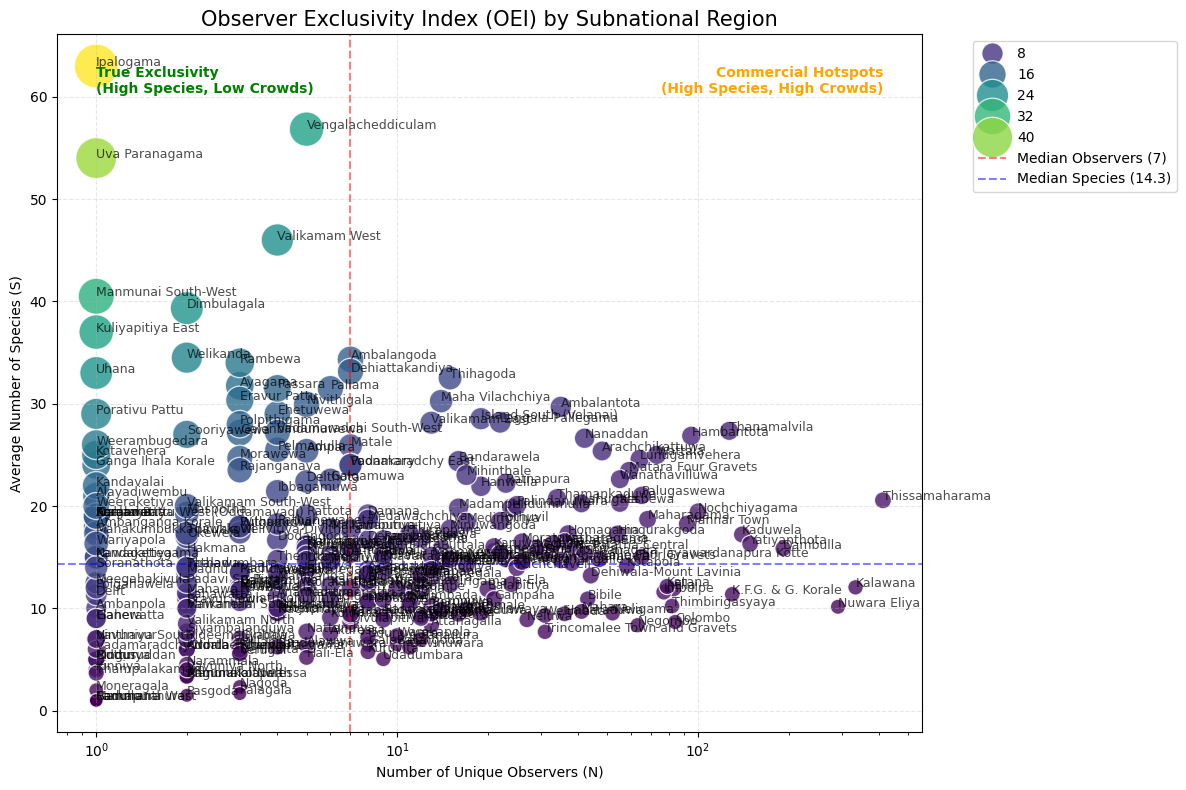

Top Regions by OEI (Potential True Exclusivity):
        subnational2Name  loc_count  num_observers  avg_numSpecies        OEI
89             Ipalogama          1              1       63.000000  47.972160
249       Uva Paranagama          1              1       54.000000  41.118994
148  Manmunai South-West          1              1       40.500000  30.839246
124    Kuliyapitiya East          1              1       37.000000  28.174126
261   Vengalacheddiculam          4              5       56.833333  27.810512
..                   ...        ...            ...             ...        ...
193             Palagala          2              3        1.666667   0.955839
131            Lankapura          1              1        1.000000   0.761463
149        Manmunai West          1              1        1.000000   0.761463
19               Badulla          1              1        1.000000   0.761463
223         Sammanthurai          1              1        1.000000   0.761463

[284 rows x 5 

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Non-weighted Observer Exlcusivity Index (OEI) Calculation by Subnational Region
# numSpecies / ln(number of unique observers + e)

# Include subnational2Name for grouping
unique_checklists_region = df[['time_stamp_utc','locId', 'subnational2Name', 'numSpecies_x', 'userDisplayName']].drop_duplicates()

# Group by subnational2Name
region_stats = unique_checklists_region.groupby('subnational2Name').agg(
    num_observers=('userDisplayName', 'nunique'),
    avg_numSpecies=('numSpecies_x', 'mean'),
    loc_count=('locId', 'nunique')
).reset_index()

# Calculate OEI
# Formula: numSpecies / ln(number of unique observers + e)
region_stats['OEI'] = region_stats['avg_numSpecies'] / np.log(region_stats['num_observers'] + np.e)

# Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=region_stats, 
    x='num_observers', 
    y='avg_numSpecies', 
    hue='OEI', 
    palette='viridis', 
    size='OEI', 
    sizes=(100, 1000),
    alpha=0.8
)

# Add reference lines for median values to define quadrants
median_obs = region_stats['num_observers'].median()
median_species = region_stats['avg_numSpecies'].median()

plt.axvline(x=median_obs, color='red', linestyle='--', alpha=0.5, label=f'Median Observers ({median_obs:.0f})')
plt.axhline(y=median_species, color='blue', linestyle='--', alpha=0.5, label=f'Median Species ({median_species:.1f})')

# Annotate Regions
for i in range(region_stats.shape[0]):
    plt.text(
        x=region_stats.num_observers[i], 
        y=region_stats.avg_numSpecies[i], 
        s=region_stats.subnational2Name[i], 
        fontdict=dict(color='black', size=9),
        alpha=0.7
    )

# Annotate Clusters (True Exclusivity vs Commercial Hotspots)
# Cluster 1: High Species, Low Observers (Top Left)
plt.text(x=region_stats['num_observers'].min(), y=region_stats['avg_numSpecies'].max(), 
         s='True Exclusivity\n(High Species, Low Crowds)', 
         fontsize=10, color='green', ha='left', va='top', fontweight='bold')

# Cluster 2: High Species, High Observers (Top Right)
plt.text(x=region_stats['num_observers'].max(), y=region_stats['avg_numSpecies'].max(), 
         s='Commercial Hotspots\n(High Species, High Crowds)', 
         fontsize=10, color='orange', ha='right', va='top', fontweight='bold')

plt.title('Observer Exclusivity Index (OEI) by Subnational Region', fontsize=15)
plt.xlabel('Number of Unique Observers (N)')
plt.xscale('log')
plt.ylabel('Average Number of Species (S)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Show top regions by OEI (High Species, Low Observers)
print("Top Regions by OEI (Potential True Exclusivity):")
print(region_stats.sort_values('OEI', ascending=False)[['subnational2Name', 'loc_count', 'num_observers', 'avg_numSpecies', 'OEI']])